In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering

In [2]:
df=pd.read_csv("data.csv")

In [3]:
df

,ID,Name,Age,Salary,Department,Address(USA city),Tax return Amount ($)
0,1,Jonas,25.0,35000,HR,"Phoenix, AZ",6878
1,2,nick,30.0,42000,IT,"Houston, TX",10728
2,3,Charlie,28.0,39000,Finance,"Chicago, IL",9718
3,4,David,35.0,52000,IT,"Charlotte, NC",8947
4,5,Eva,26.0,36000,HR,"Philadelphia, PA",2918
...,...,...,...,...,...,...,...
4948,44,Rachel,30.0,41000,HR,"Chicago, IL",3805
4949,38,Linda,34.0,55000,Finance,"Columbus, OH",2221
4950,37,Kevin,31.0,43000,Sales,"Seattle, WA",10132
4951,97,Tito,39.0,250000,Sales,"Los Angeles, CA",5952


In [4]:
df.isnull().sum()

ID                         0
Name                       0
Age                      480
Salary                     0
Department                 0
Address(USA city)          0
Tax return Amount ($)      0
dtype: int64

In [5]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

In [6]:
df.isnull().sum()

ID                       0
Name                     0
Age                      0
Salary                   0
Department               0
Address(USA city)        0
Tax return Amount ($)    0
dtype: int64

In [7]:
df.columns

Index(['ID', 'Name', 'Age', 'Salary', 'Department', 'Address(USA city)',
       'Tax return Amount ($)'],
      dtype='str')

In [8]:
df.columns = df.columns.str.strip()

In [9]:
X = df[["Age", "Salary"]]

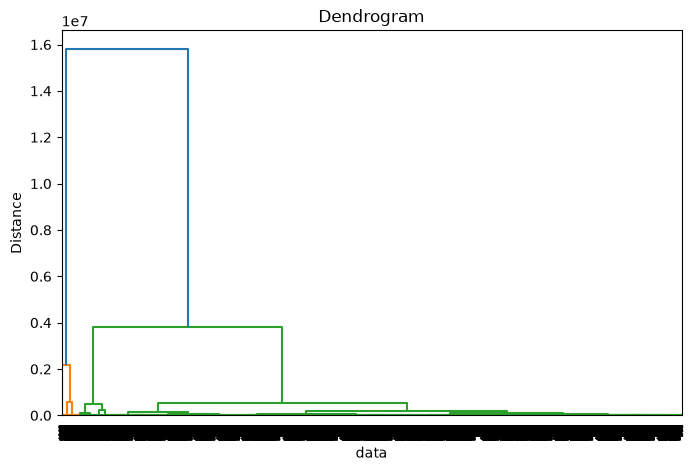

In [11]:
linked = linkage(X, method="ward")

plt.figure(figsize=(8,5))
dendrogram(linked)

plt.title("Dendrogram")
plt.xlabel("data")
plt.ylabel("Distance")

plt.show()

In [12]:
model = AgglomerativeClustering(n_clusters=3)

clusters = model.fit_predict(X)

In [13]:
df["Cluster"] = clusters

print(df.head())

   ID     Name   Age  Salary Department Address(USA city)  \
0   1    Jonas  25.0   35000         HR       Phoenix, AZ   
1   2     nick  30.0   42000         IT       Houston, TX   
2   3  Charlie  28.0   39000    Finance       Chicago, IL   
3   4    David  35.0   52000         IT     Charlotte, NC   
4   5      Eva  26.0   36000         HR  Philadelphia, PA   

   Tax return Amount ($)  Cluster  
0                   6878        1  
1                  10728        1  
2                   9718        1  
3                   8947        1  
4                   2918        1  


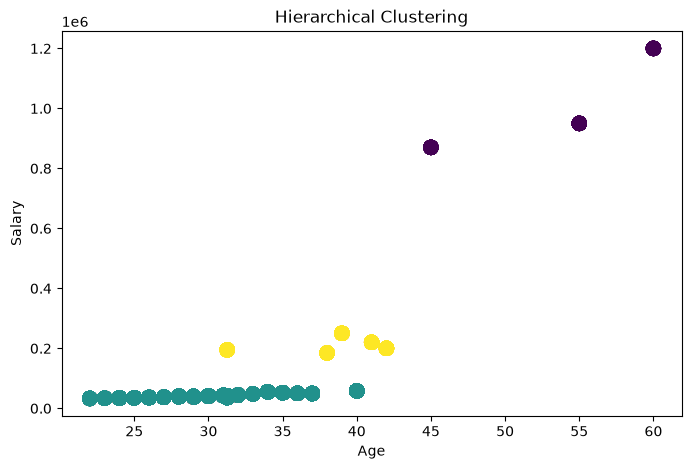

In [17]:
plt.figure(figsize=(8,5))

plt.scatter(
    X["Age"],
    X["Salary"],
    c=clusters,
    s=100
)

plt.title("Hierarchical Clustering")
plt.xlabel("Age")
plt.ylabel("Salary")

plt.show()

In [ ]:
X = df[["Age", "Salary"]]